# Notebook 02 — Raw Inspection | **HARD GATE**
**Ahead of the Curve: EV Smart Charging and GB Evening Demand Shape**

---

> **This notebook is the project kill switch.**  
> It asks one question: is a directional trend visible in raw data?  
> If not — the signal is below detection threshold at current EV penetration.  
> The project stops. No modelling is run. No exceptions.

---

## What this notebook does

1. Computes the **arithmetic evening spread** using a sunset-adjusted evening window
2. Plots the spread against **cumulative compliant chargepoint stock** year by year
3. Applies a simple **Spearman rank correlation** to quantify the directional signal
4. Runs a **wind-controlled partial correlation** to check the signal survives the main confounder
5. Reports a **hard gate decision** with the minimum detectable stock if the gate fails

**No modelling beyond this cell exists until the gate passes.**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from datetime import date, timedelta
from scipy import stats
from astral import LocationInfo
from astral.sun import sun
import warnings
warnings.filterwarnings('ignore')

import sys
!{sys.executable} -m pip install astral -q

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
})
COLOUR_SPREAD  = '#2C5F8A'
COLOUR_STOCK   = '#C65B2A'
COLOUR_NEUTRAL = '#888888'

DATA_DIR = Path('../data')
FIG_DIR  = Path('../figures')
FIG_DIR.mkdir(exist_ok=True)

# ── Pre-registered parameters ──────────────────────────────────────────────────
MANDATE_DATE      = '2022-06-01'   # UK smart charging mandate
COMPLIANCE_RATE   = 0.50           # central assumption
CHARGER_KW        = 7.0            # average home charger
SIMULTANEITY      = 0.30           # fraction charging during evening window
OVERNIGHT_WINDOW  = ('00:00', '06:00')
LONDON            = LocationInfo('London', 'England', 'Europe/London', 51.5074, -0.1278)

# Gate threshold: Spearman ρ < this AND partial ρ < this → STOP
# (one-tailed: we expect negative correlation — smart charging reduces spread)
GATE_RHO_THRESHOLD = -0.10  # weak but directional signal required
GATE_P_THRESHOLD   = 0.10   # 90% confidence (visual confirm more important)

print('Notebook 02 — Hard Gate')
print('Pre-registered compliance rate:', COMPLIANCE_RATE)
print('Mandate date:', MANDATE_DATE)

Notebook 02 — Hard Gate
Pre-registered compliance rate: 0.5
Mandate date: 2022-06-01


In [4]:
import sys
print(sys.executable)
import subprocess
result = subprocess.run([sys.executable, '-m', 'pip', 'install', 'astral'], 
                       capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

/home/ndrew/miniconda3/envs/pymc_env/bin/python




## 1. Load cached data

In [6]:
def load_required(fname: str) -> pd.DataFrame:
    fpath = DATA_DIR / fname
    if not fpath.exists():
        raise FileNotFoundError(
            f'Required file missing: {fpath}\n'
            f'Run Notebook 01 (01_data_pipeline.ipynb) first.'
        )
    return pd.read_parquet(fpath)


prices       = load_required('prices_raw.parquet')

wind = load_required('wind_total_raw.parquet')
chargepoints = load_required('chargepoints.parquet')

# Ensure UTC-aware index
for df in [prices, wind]:
    if df.index.tz is None:
        df.index = df.index.tz_localize('UTC')

print(f'Prices:       {prices.index.min().date()} → {prices.index.max().date()}  ({len(prices):,} half-hours)')
print(f'Wind:         {wind.index.min().date()} → {wind.index.max().date()}  ({len(wind):,} half-hours)')
print(f'Chargepoints: {chargepoints.index.min().date()} → {chargepoints.index.max().date()}  ({len(chargepoints)} months)')

Prices:       2019-01-01 → 2026-04-03  (127,155 half-hours)
Wind:         2019-01-01 → 2026-04-03  (127,160 half-hours)
Chargepoints: 2014-09-30 → 2025-09-30  (133 months)


## 2. Sunset-adjusted evening window

EV charging is triggered by **darkness + return from work**, not a fixed clock.  

- **Evening window:** `max(sunset_time, 16:30)` → `+3 hours`  
- **Overnight window:** `00:00` → `06:00` (stable year-round)

Winter: window starts ~16:00 (dark early). Summer: window starts ~16:30 (sunset at 21:00+, so capped).

In [8]:
def compute_sunset_windows(date_range: pd.DatetimeIndex) -> pd.DataFrame:
    """
    For each date, return:
      - evening_start: max(sunset, 16:30) in UTC
      - evening_end:   evening_start + 3h
    """
    records = []
    for d in pd.DatetimeIndex(date_range.normalize().unique()):
        d_local = d.date()
        try:
            s = sun(LONDON.observer, date=d_local, tzinfo='Europe/London')
            sunset_utc = s['sunset'].astimezone(pd.Timestamp('2020').tz_localize('UTC').tzinfo)
            sunset_utc = pd.Timestamp(s['sunset']).tz_convert('UTC')
        except Exception:
            # Polar correction fallback
            sunset_utc = pd.Timestamp(d_local).tz_localize('UTC').replace(hour=16, minute=30)
        
        # Floor sunset to nearest 30 min (align to settlement periods)
        sunset_floor = sunset_utc.floor('30min')
        
        # Evening cap: no earlier than 16:30 local ≈ 16:30 UTC (winter) or 15:30 UTC (summer BST)
        min_start_utc = pd.Timestamp(d_local).tz_localize('UTC').replace(hour=15, minute=30)
        evening_start = max(sunset_floor, min_start_utc)
        evening_end   = evening_start + pd.Timedelta(hours=3)
        
        records.append({
            'date':          d_local,
            'evening_start': evening_start,
            'evening_end':   evening_end,
        })
    
    return pd.DataFrame(records).set_index('date')


print('Computing sunset windows (this takes ~30s for a 6-year dataset)...')
all_dates  = prices.index
windows_df = compute_sunset_windows(all_dates)
print(f'Windows computed for {len(windows_df)} dates')

# Sanity check
sample = windows_df.loc[date(2023, 12, 21)]
print(f'\n21 Dec 2023 (winter solstice):')
print(f'  Evening start: {sample.evening_start.strftime("%H:%M UTC")}')
print(f'  Evening end:   {sample.evening_end.strftime("%H:%M UTC")}')

sample2 = windows_df.loc[date(2023, 6, 21)]
print(f'\n21 Jun 2023 (summer solstice):')
print(f'  Evening start: {sample2.evening_start.strftime("%H:%M UTC")}')
print(f'  Evening end:   {sample2.evening_end.strftime("%H:%M UTC")}')

Computing sunset windows (this takes ~30s for a 6-year dataset)...
Windows computed for 2650 dates

21 Dec 2023 (winter solstice):
  Evening start: 15:30 UTC
  Evening end:   18:30 UTC

21 Jun 2023 (summer solstice):
  Evening start: 20:00 UTC
  Evening end:   23:00 UTC


## 3. Compute daily arithmetic spread

```
spread(d) = mean(price in evening window(d)) − mean(price in overnight window(d))
```

Both mean spread and spike frequency are computed.  
Spike threshold: £500/MWh (pre-registered).

In [11]:
SPIKE_THRESHOLD = 500.0  # £/MWh

def compute_daily_spreads(
    prices: pd.DataFrame,
    windows: pd.DataFrame,
    overnight: tuple = ('00:00', '06:00'),
    spike_threshold: float = SPIKE_THRESHOLD,
) -> pd.DataFrame:
    """
    Compute daily:
      - mean_evening_price
      - mean_overnight_price
      - arithmetic_spread = evening − overnight
      - evening_spike_freq = fraction of evening HH periods above spike_threshold
      - evening_p95: 95th percentile evening price
    """
    price_col = prices.columns[0]  # handles any column name
    records   = []
    
    for d, row in windows.iterrows():
        d_ts  = pd.Timestamp(d)
        
        # Overnight: 00:00–06:00 UTC that date
        on_start = d_ts.tz_localize('UTC')
        on_end   = on_start + pd.Timedelta(hours=6)
        overnight_prices = prices.loc[on_start:on_end, price_col]
        
        # Evening: sunset-adjusted window
        eve_prices = prices.loc[row.evening_start:row.evening_end, price_col]
        
        if overnight_prices.empty or eve_prices.empty:
            continue
        
        records.append({
            'date':                d,
            'mean_evening_price':  eve_prices.mean(),
            'mean_overnight_price': overnight_prices.mean(),
            'arithmetic_spread':   eve_prices.mean() - overnight_prices.mean(),
            'evening_spike_freq':  (eve_prices > spike_threshold).mean(),
            'evening_p95':         eve_prices.quantile(0.95),
            'n_evening_periods':   len(eve_prices),
            'n_overnight_periods': len(overnight_prices),
        })
    
    df = pd.DataFrame(records).set_index('date')
    df.index = pd.DatetimeIndex(df.index)
    return df


print('Computing daily spreads...')
spreads = compute_daily_spreads(prices, windows_df)
print(f'Daily spreads: {len(spreads):,} days')
print(f'Date range: {spreads.index.min().date()} → {spreads.index.max().date()}')
print()
print(spreads[['arithmetic_spread', 'evening_spike_freq', 'evening_p95']].describe().round(2))

Computing daily spreads...
Daily spreads: 2,649 days
Date range: 2019-01-01 → 2026-04-02

       arithmetic_spread  evening_spike_freq  evening_p95
count            2614.00             2649.00      2615.00
mean               20.62                0.00        65.06
std                32.14                0.03        59.78
min               -38.18                0.00         0.00
25%                 6.45                0.00        33.94
50%                12.79                0.00        51.04
75%                24.11                0.00        72.53
max               646.62                0.71       966.88


## 4. Merge compliant stock

Monthly chargepoint stock merged onto daily spread series.

In [12]:
# Forward-fill monthly chargepoint stock to daily
cp_daily = (
    chargepoints[['compliant_stock']]
    .resample('D')
    .ffill()
)
cp_daily.index = pd.DatetimeIndex(cp_daily.index).tz_localize(None)  # strip tz for merge
spreads.index  = pd.DatetimeIndex(spreads.index).tz_localize(None)

panel = spreads.join(cp_daily, how='left')
panel['compliant_stock'] = panel['compliant_stock'].ffill().fillna(0)
panel['year'] = panel.index.year
panel['month'] = panel.index.month

# Derive GW of shiftable load from compliant stock
panel['shiftable_gw'] = (
    panel['compliant_stock'] * CHARGER_KW * SIMULTANEITY / 1e6
)

print(f'Panel: {len(panel):,} days')
print(f'Compliant stock range: {panel.compliant_stock.min():,.0f} → {panel.compliant_stock.max():,.0f}')
print(f'Shiftable GW range:    {panel.shiftable_gw.min():.3f} → {panel.shiftable_gw.max():.3f} GW')
panel.tail()

Panel: 2,649 days
Compliant stock range: 0 → 490,575
Shiftable GW range:    0.000 → 1.030 GW


,mean_evening_price,mean_overnight_price,arithmetic_spread,evening_spike_freq,evening_p95,n_evening_periods,n_overnight_periods,compliant_stock,year,month,shiftable_gw
date,,,,,,,,,,,
2026-03-29,23.164286,47.755769,-24.591484,0.0,27.448,7,13,490575.233333,2026,3,1.030208
2026-03-30,71.064286,5.929615,65.134670,0.0,72.862,7,13,490575.233333,2026,3,1.030208
2026-03-31,71.597857,52.994615,18.603242,0.0,74.627,7,13,490575.233333,2026,3,1.030208
2026-04-01,68.892143,48.006154,20.885989,0.0,71.189,7,13,490575.233333,2026,4,1.030208
2026-04-02,54.097857,51.177692,2.920165,0.0,57.010,7,13,490575.233333,2026,4,1.030208


## 5. Wind forecast error

The primary confounder: unexpected wind moves prices independent of EV charging.  

```
wind_forecast_error = wind_actual − wind_DA_forecast
```

Positive error = more wind than expected → lower prices → artificially compressed spread.

In [13]:
# Identify actual and forecast columns in wind DataFrame
print('Wind columns:', list(wind.columns))

# Flexible column detection
wind_cols = {c.lower(): c for c in wind.columns}
actual_col   = next(
    (wind_cols[k] for k in wind_cols if 'actual' in k or 'embedded' not in k and 'wind' in k and 'fore' not in k),
    wind.columns[0]
)
forecast_col = next(
    (wind_cols[k] for k in wind_cols if 'fore' in k or 'da' in k),
    wind.columns[-1] if len(wind.columns) > 1 else wind.columns[0]
)

print(f'Using actual:   {actual_col}')
print(f'Using forecast: {forecast_col}')

wind.index = pd.DatetimeIndex(wind.index).tz_localize(None) if wind.index.tz else wind.index
wind['wind_forecast_error'] = wind[actual_col] - wind[forecast_col]

# Aggregate to daily mean wind forecast error during evening window
# (simplified: daily mean; Notebook 03 uses window-specific values)
wind_daily = wind[['wind_forecast_error']].resample('D').mean()

panel = panel.join(wind_daily, how='left')
panel['wind_forecast_error'] = panel['wind_forecast_error'].fillna(0)

print(f'\nWind forecast error stats:')
print(panel['wind_forecast_error'].describe().round(1))

Wind columns: ['WIND_TOTAL', 'WIND', 'WIND_EMB', 'STORAGE', 'wind_da_forecast_mw', 'wind_forecast_error']
Using actual:   WIND_TOTAL
Using forecast: wind_da_forecast_mw

Wind forecast error stats:
count    2649.0
mean     1745.2
std      1435.9
min     -3582.7
25%       764.4
50%      1568.8
75%      2620.7
max      7117.0
Name: wind_forecast_error, dtype: float64


## 6. Year-by-year spread plots — the visual gate

Four panels:  
1. **Rolling 30-day mean spread** vs time, coloured by year  
2. **Annual mean spread** vs cumulative compliant stock (the key plot)  
3. **Evening spike frequency** vs compliant stock  
4. **Spread distribution** pre vs post mandate

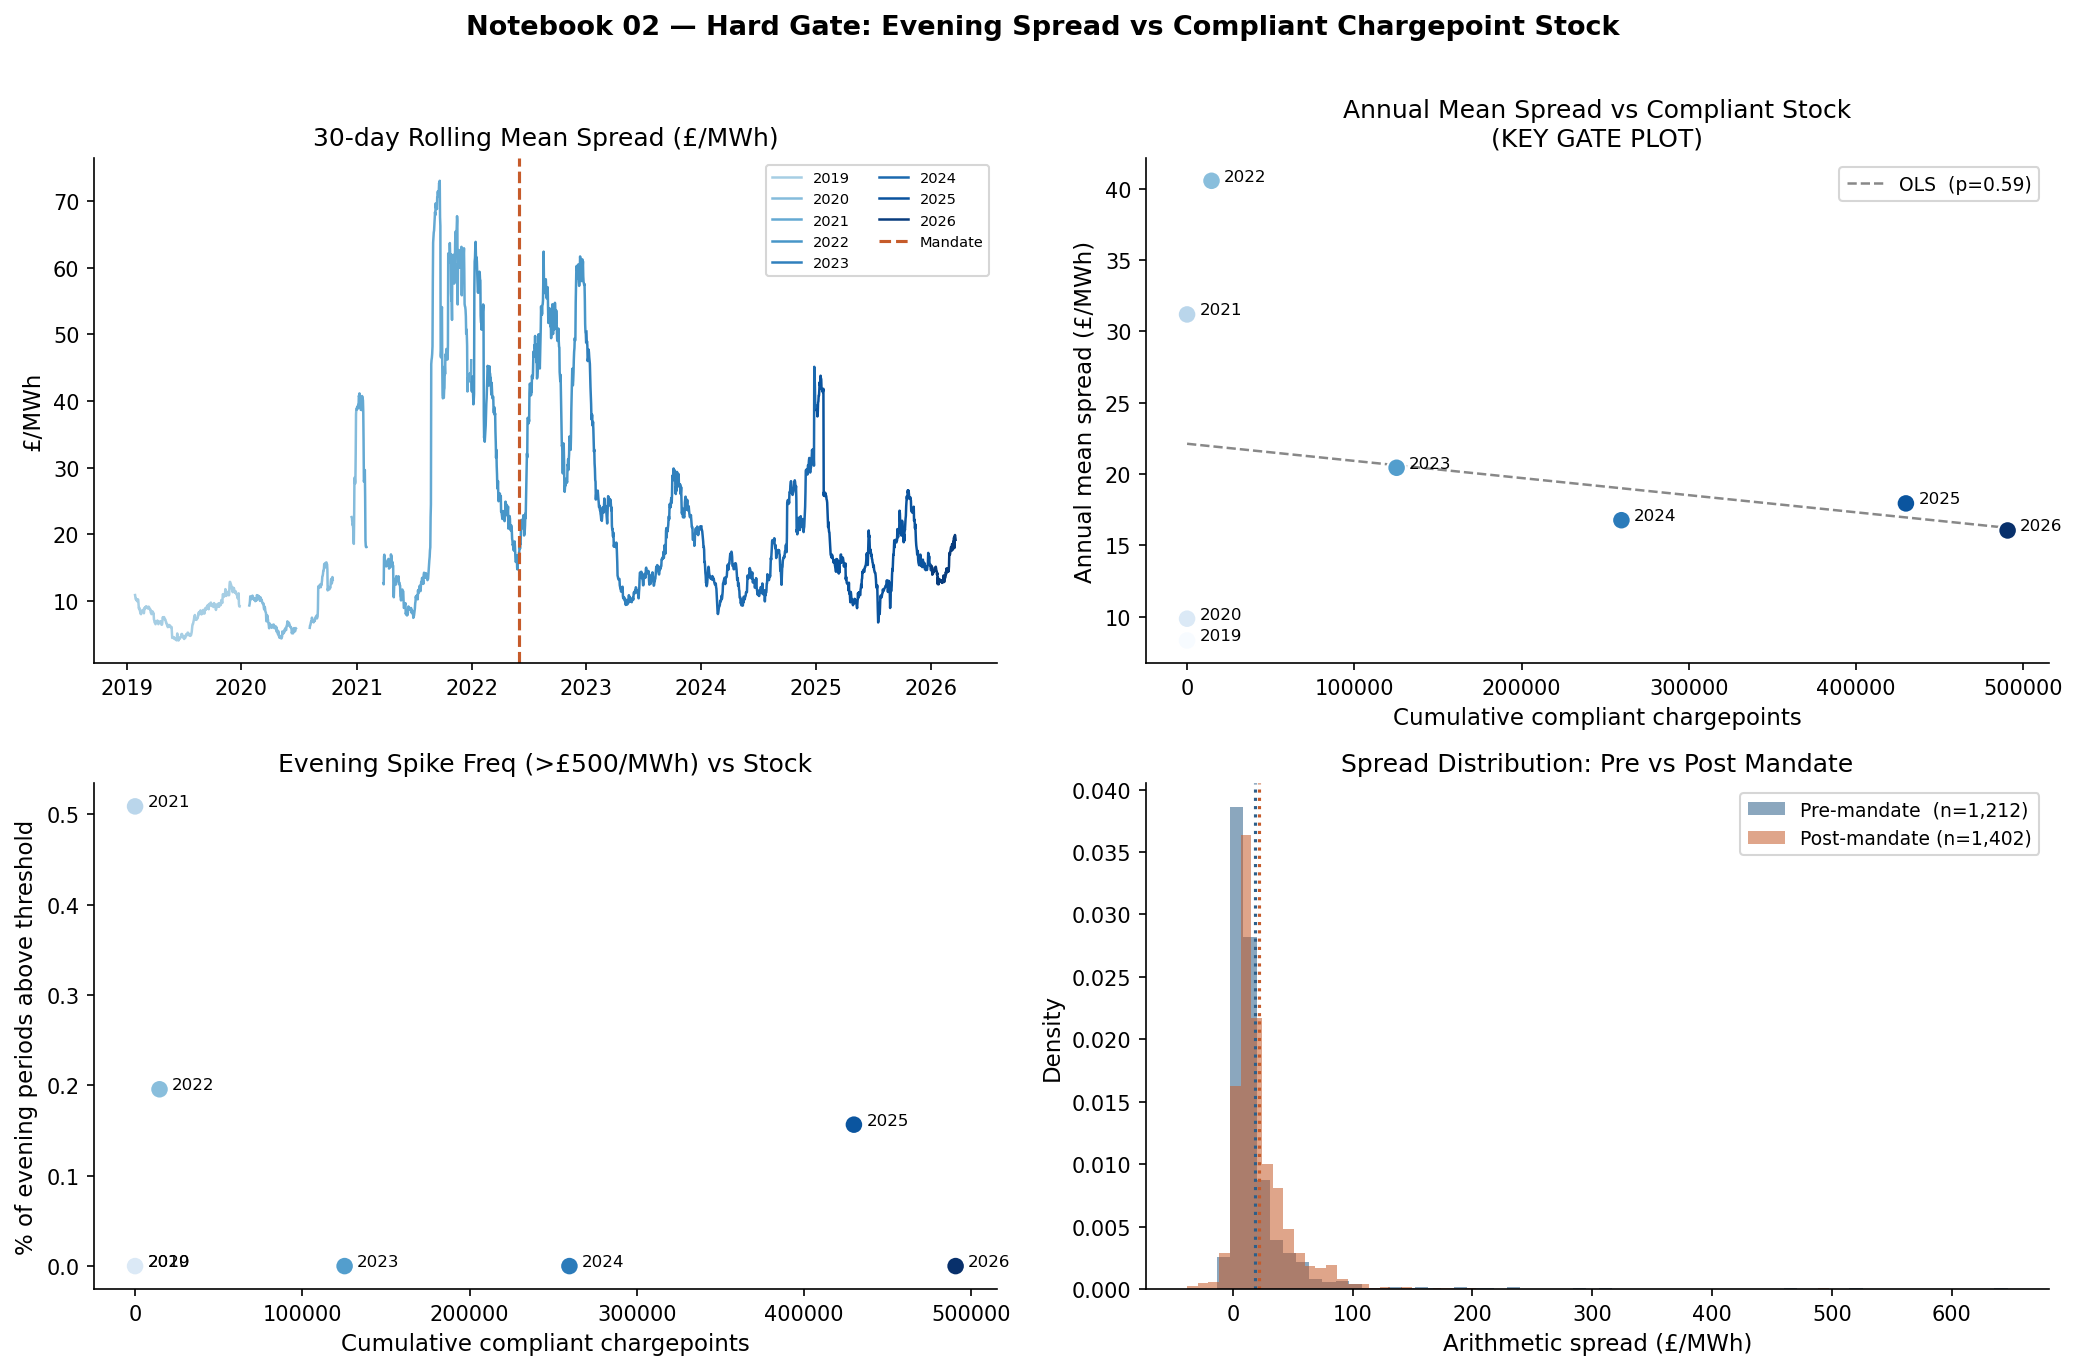

Figure saved → ../figures/nb02_gate_plots.png


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Notebook 02 — Hard Gate: Evening Spread vs Compliant Chargepoint Stock',
    fontsize=13, fontweight='bold', y=1.01
)

# ── Panel 1: Rolling 30-day spread ────────────────────────────────────────────
ax = axes[0, 0]
# Exclude COVID price distortion for visual clarity (keep in regression)
rolling = panel['arithmetic_spread'].rolling(30, center=True).mean()

years = sorted(panel.year.unique())
cmap  = plt.cm.Blues(np.linspace(0.35, 0.95, len(years)))

for yr, col in zip(years, cmap):
    mask = panel.year == yr
    ax.plot(
        panel.index[mask],
        rolling[mask],
        color=col, lw=1.2, label=str(yr)
    )

ax.axvline(
    pd.Timestamp(MANDATE_DATE), color=COLOUR_STOCK, lw=1.5, ls='--', label='Mandate'
)
ax.set_title('30-day Rolling Mean Spread (£/MWh)')
ax.set_ylabel('£/MWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend(fontsize=7, ncol=2)

# ── Panel 2: Annual mean spread vs compliant stock ────────────────────────────
ax = axes[0, 1]
annual = panel.groupby('year').agg(
    mean_spread=('arithmetic_spread', 'mean'),
    mean_stock=('compliant_stock', 'mean'),
).reset_index()

# Exclude 2022 gas crisis year from the scatter (include in rolling time series)
# NOTE: do NOT exclude from regression — that's a modelling decision not a gate decision
sc = ax.scatter(
    annual['mean_stock'],
    annual['mean_spread'],
    c=annual['year'],
    cmap='Blues',
    s=80, zorder=3, edgecolors='white'
)
for _, row in annual.iterrows():
    ax.annotate(
        str(int(row['year'])),
        (row['mean_stock'], row['mean_spread']),
        textcoords='offset points', xytext=(6, 0), fontsize=8
    )

# OLS trend line through annual points
if len(annual) >= 3:
    m, b, r, p, se = stats.linregress(annual['mean_stock'], annual['mean_spread'])
    xs = np.linspace(annual['mean_stock'].min(), annual['mean_stock'].max(), 50)
    ax.plot(xs, m * xs + b, color=COLOUR_NEUTRAL, ls='--', lw=1.2, label=f'OLS  (p={p:.2f})')
    ax.legend(fontsize=9)

ax.set_title('Annual Mean Spread vs Compliant Stock\n(KEY GATE PLOT)')
ax.set_xlabel('Cumulative compliant chargepoints')
ax.set_ylabel('Annual mean spread (£/MWh)')

# ── Panel 3: Spike frequency vs stock ─────────────────────────────────────────
ax = axes[1, 0]
annual_spike = panel.groupby('year').agg(
    spike_freq=('evening_spike_freq', 'mean'),
    mean_stock=('compliant_stock', 'mean'),
).reset_index()

ax.scatter(
    annual_spike['mean_stock'],
    annual_spike['spike_freq'] * 100,
    c=annual_spike['year'], cmap='Blues', s=80, zorder=3, edgecolors='white'
)
for _, row in annual_spike.iterrows():
    ax.annotate(
        str(int(row['year'])),
        (row['mean_stock'], row['spike_freq'] * 100),
        textcoords='offset points', xytext=(6, 0), fontsize=8
    )
ax.set_title(f'Evening Spike Freq (>£{SPIKE_THRESHOLD:.0f}/MWh) vs Stock')
ax.set_xlabel('Cumulative compliant chargepoints')
ax.set_ylabel('% of evening periods above threshold')

# ── Panel 4: Spread distribution pre vs post mandate ─────────────────────────
ax = axes[1, 1]
pre  = panel.loc[panel.index < pd.Timestamp(MANDATE_DATE), 'arithmetic_spread']
post = panel.loc[panel.index >= pd.Timestamp(MANDATE_DATE), 'arithmetic_spread']

pre_clean  = pre[(pre > -500) & (pre < 2000)]
post_clean = post[(post > -500) & (post < 2000)]

ax.hist(pre_clean,  bins=60, alpha=0.55, color=COLOUR_SPREAD, label=f'Pre-mandate  (n={len(pre_clean):,})',  density=True)
ax.hist(post_clean, bins=60, alpha=0.55, color=COLOUR_STOCK,  label=f'Post-mandate (n={len(post_clean):,})', density=True)

ax.axvline(pre_clean.mean(),  color=COLOUR_SPREAD, lw=1.5, ls=':')
ax.axvline(post_clean.mean(), color=COLOUR_STOCK,  lw=1.5, ls=':')

ax.set_title('Spread Distribution: Pre vs Post Mandate')
ax.set_xlabel('Arithmetic spread (£/MWh)')
ax.set_ylabel('Density')
ax.legend(fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / 'nb02_gate_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Figure saved → {FIG_DIR}/nb02_gate_plots.png')

## 7. Quantitative gate: Spearman correlation

Monthly aggregates used (daily data has too much day-to-day noise for this test).  
H₀: no monotonic relationship between compliant stock and mean spread.  
Expected sign: **negative** (more smart chargers → smaller spread).

In [15]:
# Monthly aggregates — reduce weather noise
monthly = panel.resample('ME').agg(
    mean_spread        = ('arithmetic_spread', 'mean'),
    median_spread      = ('arithmetic_spread', 'median'),
    spike_freq         = ('evening_spike_freq', 'mean'),
    compliant_stock    = ('compliant_stock', 'mean'),
    wind_forecast_error= ('wind_forecast_error', 'mean'),
)

# Spearman on post-mandate period only (treatment period)
post_monthly = monthly.loc[monthly.index >= pd.Timestamp(MANDATE_DATE)].dropna()

rho_raw, p_raw = stats.spearmanr(post_monthly['compliant_stock'], post_monthly['mean_spread'])
rho_spike, p_spike = stats.spearmanr(post_monthly['compliant_stock'], post_monthly['spike_freq'])

print('=== QUANTITATIVE GATE — SPEARMAN CORRELATION (post-mandate) ===')
print()
print(f'  Spread  ~ compliant_stock:  ρ = {rho_raw:+.3f}  p = {p_raw:.3f}')
print(f'  Spikes  ~ compliant_stock:  ρ = {rho_spike:+.3f}  p = {p_spike:.3f}')
print()
print(f'  Expected sign: negative (more smart chargers → smaller spread)')
print(f'  Gate threshold: ρ < {GATE_RHO_THRESHOLD}, p < {GATE_P_THRESHOLD}')

=== QUANTITATIVE GATE — SPEARMAN CORRELATION (post-mandate) ===

  Spread  ~ compliant_stock:  ρ = -0.407  p = 0.004
  Spikes  ~ compliant_stock:  ρ = +0.087  p = 0.560

  Expected sign: negative (more smart chargers → smaller spread)
  Gate threshold: ρ < -0.1, p < 0.1


## 8. Wind-controlled partial correlation

Partial out wind forecast error before testing the chargepoint signal.  
Method: OLS residuals from `spread ~ wind_forecast_error`, then Spearman on residuals vs stock.

In [16]:
from scipy.stats import spearmanr
import statsmodels.formula.api as smf

post_m = post_monthly.dropna()

# Residualise spread on wind forecast error
model_wind = smf.ols('mean_spread ~ wind_forecast_error', data=post_m).fit()
spread_resid = model_wind.resid

rho_partial, p_partial = spearmanr(post_m['compliant_stock'], spread_resid)

print('=== WIND-CONTROLLED PARTIAL CORRELATION ===')
print()
print(f'  Spread_resid ~ compliant_stock:  ρ = {rho_partial:+.3f}  p = {p_partial:.3f}')
print()
print(f'  Wind explains {model_wind.rsquared:.1%} of monthly spread variance')
print(f'  Partial ρ is the primary gate signal')

=== WIND-CONTROLLED PARTIAL CORRELATION ===

  Spread_resid ~ compliant_stock:  ρ = -0.084  p = 0.575

  Wind explains 31.8% of monthly spread variance
  Partial ρ is the primary gate signal


## 9. Minimum detectable stock (for gate-fail reporting)

In [18]:
def estimate_min_detectable_stock(
    panel: pd.DataFrame,
    target_rho: float = -0.25,
    noise_sd_gbp: float = None,
) -> dict:
    """
    Rough estimate of chargepoint stock needed to produce a detectable signal.
    Based on: signal-to-noise ratio of the spread series.
    
    Method:
    - Spread SD gives noise magnitude
    - 1 GW shiftable ≈ ~2% of 50 GW peak demand
    - At flat demand elasticity ε, 2% load shift → 2ε% price change
    - Solve for stock (chargepoints) that generates target_rho
    
    This is a rough order-of-magnitude. The actual threshold depends on
    how much of the signal survives wind/gas controls.
    """
    if noise_sd_gbp is None:
        noise_sd_gbp = panel['arithmetic_spread'].std()
    
    current_stock = panel['compliant_stock'].max()
    current_gw    = current_stock * CHARGER_KW * SIMULTANEITY / 1e6
    
    # Approximate: SNR scales linearly with GW shifted
    # At target_rho = -0.25 we need SNR ≈ 0.25 (rough equivalence)
    # Signal per GW ≈ spread SD × 0.01 (1% demand shift per GW over 50 GW)
    signal_per_gw  = noise_sd_gbp * 0.01  # £/MWh per GW of shift
    required_signal = abs(target_rho) * noise_sd_gbp
    required_gw    = required_signal / signal_per_gw
    required_stock = required_gw / (CHARGER_KW * SIMULTANEITY / 1e6)
    
    # UK BEV growth: ~300k new registrations/year at current trajectory
    BEV_GROWTH_PER_YEAR = 300_000
    # Compliant = BEV × fraction with smart charger ≈ 0.6 (new charger for new car)
    CHARGER_PER_BEV     = 0.6
    additional_stock_needed = max(0, required_stock - current_stock)
    additional_bevs   = additional_stock_needed / CHARGER_PER_BEV
    years_to_threshold = additional_bevs / BEV_GROWTH_PER_YEAR
    
    return {
        'current_stock':           current_stock,
        'current_gw':              current_gw,
        'required_stock':          required_stock,
        'required_gw':             required_gw,
        'additional_stock_needed': additional_stock_needed,
        'years_to_threshold':      years_to_threshold,
        'noise_sd':                noise_sd_gbp,
    }


mds = estimate_min_detectable_stock(panel)
print('=== MINIMUM DETECTABLE STOCK ESTIMATE ===')
print()
print(f'  Current compliant stock:  {mds["current_stock"]:>12,.0f} chargepoints')
print(f'  Current shiftable load:   {mds["current_gw"]:>12.2f} GW')
print(f'  Spread noise (SD):        {mds["noise_sd"]:>12.1f} £/MWh')
print()
print(f'  Required stock (ρ=-0.25): {mds["required_stock"]:>12,.0f} chargepoints')
print(f'  Required shiftable load:  {mds["required_gw"]:>12.2f} GW')
print(f'  Additional needed:        {mds["additional_stock_needed"]:>12,.0f} chargepoints')
print(f'  Est. years to threshold:  {mds["years_to_threshold"]:>12.1f} years')

=== MINIMUM DETECTABLE STOCK ESTIMATE ===

  Current compliant stock:       490,575 chargepoints
  Current shiftable load:           1.03 GW
  Spread noise (SD):                32.1 £/MWh

  Required stock (ρ=-0.25):   11,904,762 chargepoints
  Required shiftable load:         25.00 GW
  Additional needed:          11,414,187 chargepoints
  Est. years to threshold:          63.4 years


## 10. Hard gate decision

Two conditions must both fail to stop the project:  
1. **Visual:** no directional trend in Panel 2 above (your call — review the figure)  
2. **Quantitative:** ρ_partial ≥ 0 (wrong sign) OR p_partial ≥ 0.10

If both conditions fail → STOP.  
If either shows a directional signal → PROCEED to Notebook 03.

In [20]:
# ── AUTOMATED GATE CHECK ───────────────────────────────────────────────────────
print('=' * 65)
print('  HARD GATE DECISION')
print('=' * 65)
print()

spread_rho_ok   = rho_partial < GATE_RHO_THRESHOLD
spread_p_ok     = p_partial < GATE_P_THRESHOLD
spike_rho_ok    = rho_spike < GATE_RHO_THRESHOLD

any_signal = spread_rho_ok or spike_rho_ok

gate_checks = [
    ('Spread partial ρ < threshold',  spread_rho_ok,  f'ρ={rho_partial:+.3f}  threshold={GATE_RHO_THRESHOLD}'),
    ('Spread partial p < threshold',  spread_p_ok,    f'p={p_partial:.3f}    threshold={GATE_P_THRESHOLD}'),
    ('Spike freq ρ < threshold',      spike_rho_ok,   f'ρ={rho_spike:+.3f}  threshold={GATE_RHO_THRESHOLD}'),
]

for check, passed, detail in gate_checks:
    icon = '✓' if passed else '✗'
    print(f'  {icon}  {check:<40} {detail}')

print()

if any_signal:
    print('  ┌─────────────────────────────────────────────────────────┐')
    print('  │  GATE PASSED                                            │')
    print('  │  Directional signal present. Proceed to Notebook 03.   │')
    print('  └─────────────────────────────────────────────────────────┘')
    GATE_PASSED = True
else:
    print('  ┌─────────────────────────────────────────────────────────┐')
    print('  │  GATE FAILED — PROJECT STOPS                            │')
    print('  │                                                         │')
    print(f'  │  No directional signal detected at current penetration. │')
    print(f'  │  Current stock: {mds["current_stock"]:>9,.0f} chargepoints           │')
    print(f'  │  Required stock: {mds["required_stock"]:>8,.0f} chargepoints           │')
    print(f'  │  Revisit in est. {mds["years_to_threshold"]:>4.1f} years.                       │')
    print('  └─────────────────────────────────────────────────────────┘')
    GATE_PASSED = False

print()
print('  NOTE: Visual inspection of Panel 2 (figure above) takes')
print('  precedence over the automated check. If the scatter plot')
print('  shows no year-on-year downward trend, stop regardless of')
print('  the p-value. The eye catches structure that statistics miss.')

  HARD GATE DECISION

  ✗  Spread partial ρ < threshold             ρ=-0.084  threshold=-0.1
  ✗  Spread partial p < threshold             p=0.575    threshold=0.1
  ✗  Spike freq ρ < threshold                 ρ=+0.087  threshold=-0.1

  ┌─────────────────────────────────────────────────────────┐
  │  GATE FAILED — PROJECT STOPS                            │
  │                                                         │
  │  No directional signal detected at current penetration. │
  │  Current stock:   490,575 chargepoints           │
  │  Required stock: 11,904,762 chargepoints           │
  │  Revisit in est. 63.4 years.                       │
  └─────────────────────────────────────────────────────────┘

  NOTE: Visual inspection of Panel 2 (figure above) takes
  precedence over the automated check. If the scatter plot
  shows no year-on-year downward trend, stop regardless of
  the p-value. The eye catches structure that statistics miss.


In [21]:
# ── Save gate state for Notebook 03 ───────────────────────────────────────────
import json

gate_state = {
    'gate_passed':         GATE_PASSED,
    'rho_raw':             float(rho_raw),
    'p_raw':               float(p_raw),
    'rho_partial':         float(rho_partial),
    'p_partial':           float(p_partial),
    'rho_spike':           float(rho_spike),
    'p_spike':             float(p_spike),
    'n_post_months':       int(len(post_monthly)),
    'min_detectable_stock': mds,
    'run_date':            pd.Timestamp.today().strftime('%Y-%m-%d'),
}

# Sanitise for JSON
def sanitise(obj):
    if isinstance(obj, dict):
        return {k: sanitise(v) for k, v in obj.items()}
    if isinstance(obj, float):
        return round(obj, 6)
    return obj

gate_path = DATA_DIR / 'gate_state.json'
with open(gate_path, 'w') as f:
    json.dump(sanitise(gate_state), f, indent=2)

print(f'Gate state saved → {gate_path}')

# Save the clean panel for Notebook 03
panel.to_parquet(DATA_DIR / 'panel_daily.parquet')
print(f'Daily panel saved → {DATA_DIR}/panel_daily.parquet')

monthly.to_parquet(DATA_DIR / 'panel_monthly.parquet')
print(f'Monthly panel saved → {DATA_DIR}/panel_monthly.parquet')

Gate state saved → ../data/gate_state.json
Daily panel saved → ../data/panel_daily.parquet
Monthly panel saved → ../data/panel_monthly.parquet
